In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data.csv")
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
df.shape

(11914, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [6]:
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [7]:
# for all numeric columns we fill null values with median and for categorical values we fill it with mode
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())

df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())

df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].median())

df['Market Category'] = df['Market Category'].fillna(df['Market Category'].mode()[0])

df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

In [8]:
df.duplicated().sum()

np.int64(715)

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11199.000000,11199.000000,11199.000000,11199.000000,11199.000000,11199.000000,11199.000000,1.119900e+04
mean,2010.714528,253.226270,5.666845,3.454416,26.610590,19.731851,1558.483347,4.192593e+04
std,7.228211,109.830464,1.794696,0.872804,8.977641,9.177555,1445.668872,6.153505e+04
min,1990.000000,55.000000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,172.000000,4.000000,2.000000,22.000000,16.000000,549.000000,2.159950e+04
50%,2015.000000,236.000000,6.000000,4.000000,25.000000,18.000000,1385.000000,3.067500e+04
75%,2016.000000,303.000000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.303250e+04
max,2017.000000,1001.000000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [11]:
corr = df.corr(numeric_only=True)

corr

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,1.000000,0.334828,-0.034152,0.247739,0.244972,0.188417,0.085874,0.209635
Engine HP,0.334828,1.000000,0.774943,-0.129554,-0.366345,-0.359215,0.041668,0.658536
Engine Cylinders,-0.034152,0.774943,1.000000,-0.149798,-0.596246,-0.562599,0.038325,0.538531
Number of Doors,0.247739,-0.129554,-0.149798,1.000000,0.115081,0.121013,-0.057213,-0.144353
highway MPG,0.244972,-0.366345,-0.596246,0.115081,1.000000,0.886299,-0.017159,-0.166631
city mpg,0.188417,-0.359215,-0.562599,0.121013,0.886299,1.000000,-0.000549,-0.162343
Popularity,0.085874,0.041668,0.038325,-0.057213,-0.017159,-0.000549,1.000000,-0.048371
MSRP,0.209635,0.658536,0.538531,-0.144353,-0.166631,-0.162343,-0.048371,1.000000


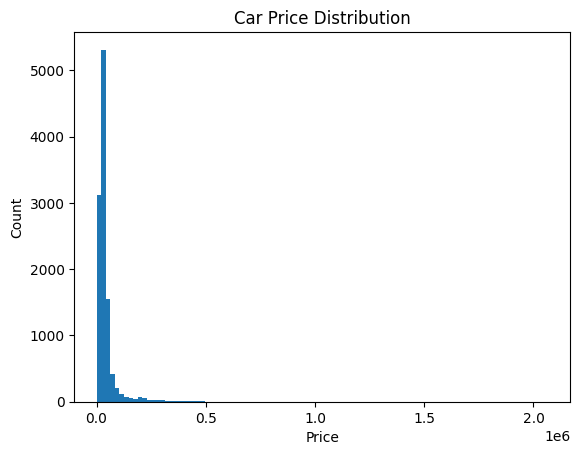

In [15]:
plt.hist(df['MSRP'], bins=100)

plt.title("Car Price Distribution")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

In [18]:
df['Make'].value_counts()

Make
Chevrolet        1083
Ford              825
Toyota            719
Volkswagen        568
Nissan            551
Dodge             529
GMC               482
Honda             433
Mazda             412
Cadillac          396
Suzuki            342
Mercedes-Benz     341
Infiniti          328
BMW               324
Audi              321
Volvo             266
Hyundai           259
Acura             246
Subaru            239
Kia               229
Mitsubishi        208
Lexus             202
Buick             190
Chrysler          187
Pontiac           181
Lincoln           160
Land Rover        139
Porsche           136
Oldsmobile        132
Saab              109
Aston Martin       91
Bentley            74
Plymouth           71
Ferrari            69
FIAT               62
Scion              60
Maserati           55
Lamborghini        52
Rolls-Royce        31
Lotus              28
Tesla              18
HUMMER             17
Maybach            16
Alfa Romeo          5
McLaren             5
Genes

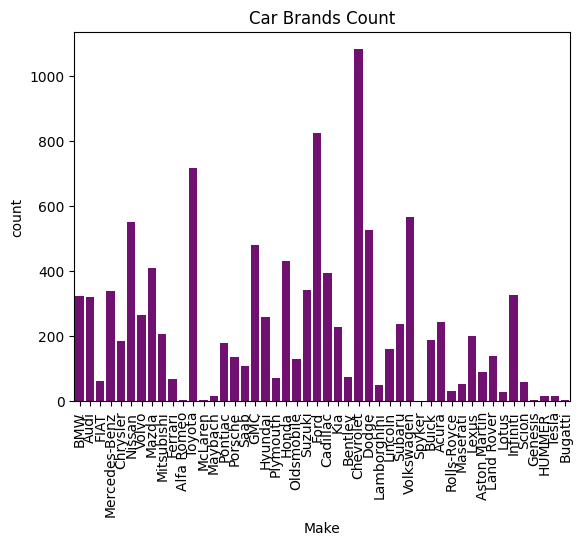

In [47]:
sns.countplot(x='Make', data=df, color="purple")

plt.title("Car Brands Count")

plt.xticks(rotation=90)

plt.show()

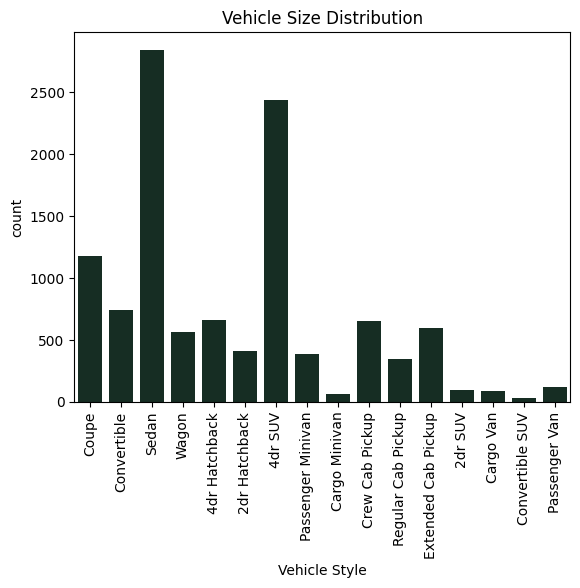

In [ ]:
sns.countplot(x='Vehicle Style', data=df, color="#123123")

plt.title("Vehicle Style Distribution")

plt.xticks(rotation=90)

plt.show()

<Axes: xlabel='Engine Cylinders', ylabel='Count'>

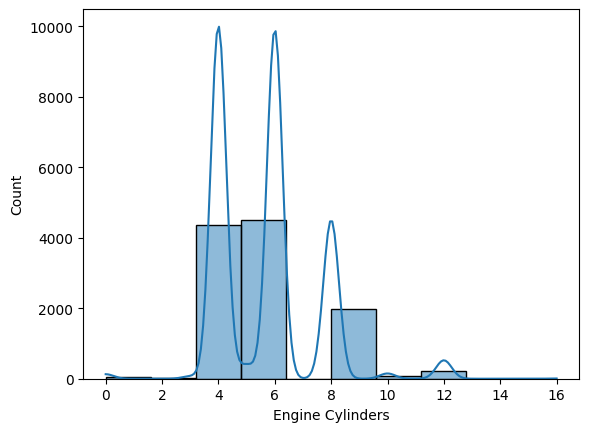

In [70]:
sns.histplot(data = df,x = "Engine Cylinders", bins = 10,kde = True)


In [82]:
df.to_csv("cleaned_data.csv", index=False)

In [ ]:
# Insights : 
# 1. The dataset contains 11,914 rows and 16 columns.
# 2. Missing values were filled using median and mode.
# 3. Duplicate rows were removed from the dataset.
# 4. Most cars belong to the medium-size vehicle category.
# 5. Automatic transmission cars are more common.
# 6. The price distribution is uneven due to high-priced luxury cars.